In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import brier_score_loss, accuracy_score

from sklearn.datasets import load_iris

In [96]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


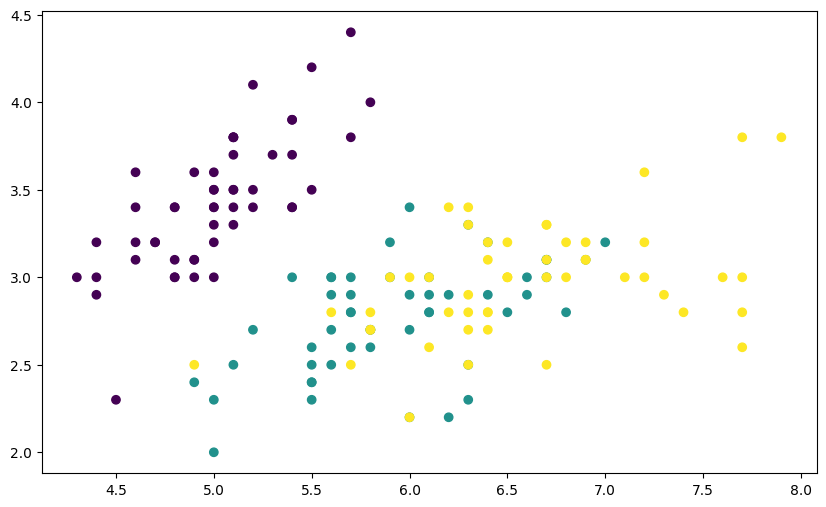

In [97]:
fig = plt.figure(figsize=(10, 6))

plt.scatter(data.data[:, 0], data.data[:, 1], c=data.target)

In [98]:
x = data.data
y = data.target

In [107]:
X.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [103]:
scores_train = []
scores_test = []
cv = KFold(n_splits=3, shuffle=True, random_state=42)
for train_ind, test_ind in cv.split(x):
    x_train, x_test, y_train, y_test = x[train_ind], x[test_ind], y[train_ind], y[test_ind]
    sc = MinMaxScaler()
    x_train = sc.fit_transform(x_train)
    x_test = sc.transform(x_test)
    model = LogisticRegression(C=5,solver="lbfgs")
    # {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, 
    model.fit(x_train, y_train)
    acc_test = accuracy_score(y_test, model.predict(x_test))
    acc_train = accuracy_score(y_train, model.predict(x_train))
    scores_test.append(acc_test)
    scores_train.append(acc_train)
print(scores_train)
print(scores_test)
np.mean(scores_train), np.mean(scores_test)

[0.95, 0.98, 0.95]
[0.98, 0.92, 0.98]


(np.float64(0.96), np.float64(0.96))